In [1]:
from ultralytics import YOLO # video segmentation and detection
import cv2 # video read/write + drawing
import supervision as sv # this is from ROBOFLOW ECOSYSTEM, used for tracking+formatting, it has built-in trackers----> ByteTrack, clean detection format and easy drawing;
import numpy as np

In [2]:
model = YOLO("yolov8x.pt")

In [5]:
# this is needed as because YOLOv8 detects everything, i just need to filter what i want;

CLASS_NAMES_DICT = model.model.names
SELECTED_CLASS_NAMES = ['person', 'sports ball']

SELECTED_CLASS_IDS = [
    {value: key for key, value in CLASS_NAMES_DICT.items()}[class_name]
    for class_name in SELECTED_CLASS_NAMES
]
print(SELECTED_CLASS_IDS)

[0, 32]


In [6]:
# the dataset  : 

SOURCE_VIDEO_PATH = r"E:\404_Found\Video Segmentation\SuperHuman Moments in FootBall\Dataset\_SuperHuman_Moments_in_Football_1080p60.mp4"

In [7]:
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH) # sv is the supervision library the fucntion reads teh video file frame by frame and retuns a generator ----> instead of loading whole video into memory(extreamly huge), it gives one frame at a time on demand(on the fly)...

# manually using the generator instead of the for loop,
iterator = iter(generator) # generator is already iterable, but this explicitly gets its iterator
frame = next(iterator) # ---> pulls ONE frame from the video
print(frame.shape)

(1080, 1920, 3)


In [ ]:
# model prediction on single frame and conversion to supervision Detections : 
results = model(frame, verbose=False)[0]  # ---> passing one frame into the YOLOv8 model, yolo runs detection and returns a list(always) thats why [0]---> means extract the first (and only) result;
detections = sv.Detections.from_ultralytics(results) # Detections = a DS, defined by sv; used to store detection results in a standardized format; YOLO---> Clean Format;
print(detections)

Detections(xyxy=array([[     547.38,      439.94,      728.08,      724.42],
       [     961.71,      365.06,      1069.5,         560],
       [     860.54,      199.91,      951.96,       365.1],
       [     534.32,      747.89,      702.68,      1077.6],
       [     545.88,      43.754,      612.94,      158.49],
       [     227.79,           0,      298.68,      95.545],
       [     1173.3,      92.028,      1237.3,      241.92],
       [     181.78,      180.15,      246.53,      350.83],
       [     496.06,      7.3257,      538.97,      131.95],
       [     614.62,     0.98426,      659.57,      65.499],
       [     1007.4,     0.32828,        1067,      67.304],
       [       1262,           0,      1291.1,      38.425],
       [        922,           0,      961.73,      60.409],
       [     1694.7,      116.86,      1758.9,      158.45],
       [     587.71,      946.56,      622.77,      976.13]], dtype=float32), mask=None, confidence=array([    0.93875,     0.9293

In [9]:
detections = detections[np.isin(detections.class_id, SELECTED_CLASS_IDS)] #  only consider class id from selected_classes define above; Operation: filter by class IDs
print(detections)

Detections(xyxy=array([[     547.38,      439.94,      728.08,      724.42],
       [     961.71,      365.06,      1069.5,         560],
       [     860.54,      199.91,      951.96,       365.1],
       [     534.32,      747.89,      702.68,      1077.6],
       [     545.88,      43.754,      612.94,      158.49],
       [     227.79,           0,      298.68,      95.545],
       [     1173.3,      92.028,      1237.3,      241.92],
       [     181.78,      180.15,      246.53,      350.83],
       [     496.06,      7.3257,      538.97,      131.95],
       [     614.62,     0.98426,      659.57,      65.499],
       [     1007.4,     0.32828,        1067,      67.304],
       [       1262,           0,      1291.1,      38.425],
       [        922,           0,      961.73,      60.409],
       [     587.71,      946.56,      622.77,      976.13]], dtype=float32), mask=None, confidence=array([    0.93875,     0.92936,     0.90909,     0.90502,     0.89579,     0.88602,     0.

In [10]:
# For each detection combine: class name + confidence score into a formatted string list

labels = []
for confidence, class_id in zip(detections.confidence, detections.class_id):
    name = CLASS_NAMES_DICT[class_id]
    label = f"{name} {confidence:0.2f}"
    labels.append(label)
print(labels)

['person 0.94', 'person 0.93', 'person 0.91', 'person 0.91', 'person 0.90', 'person 0.89', 'person 0.88', 'person 0.86', 'person 0.84', 'person 0.82', 'person 0.80', 'person 0.72', 'person 0.69', 'sports ball 0.45']


In [14]:
# create instance of BoxAnnotator and LabelAnnotator
box_annotator = sv.BoxAnnotator(thickness=1)
label_annotator = sv.LabelAnnotator(text_thickness=1, text_scale=0.6, text_color=sv.Color.BLACK)

In [15]:
# annotate and display frame
annotated_frame = frame.copy() #  Creates a separate copy of the original frame, So any drawing/annotation won’t modify the original image
annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections) # Takes that frame and draws bounding boxes on it using the objects in detections; Result: frame now has boxes around detected objects
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels) # On the same frame, adds text labels (like "car 0.91") next to each box, using your labels list

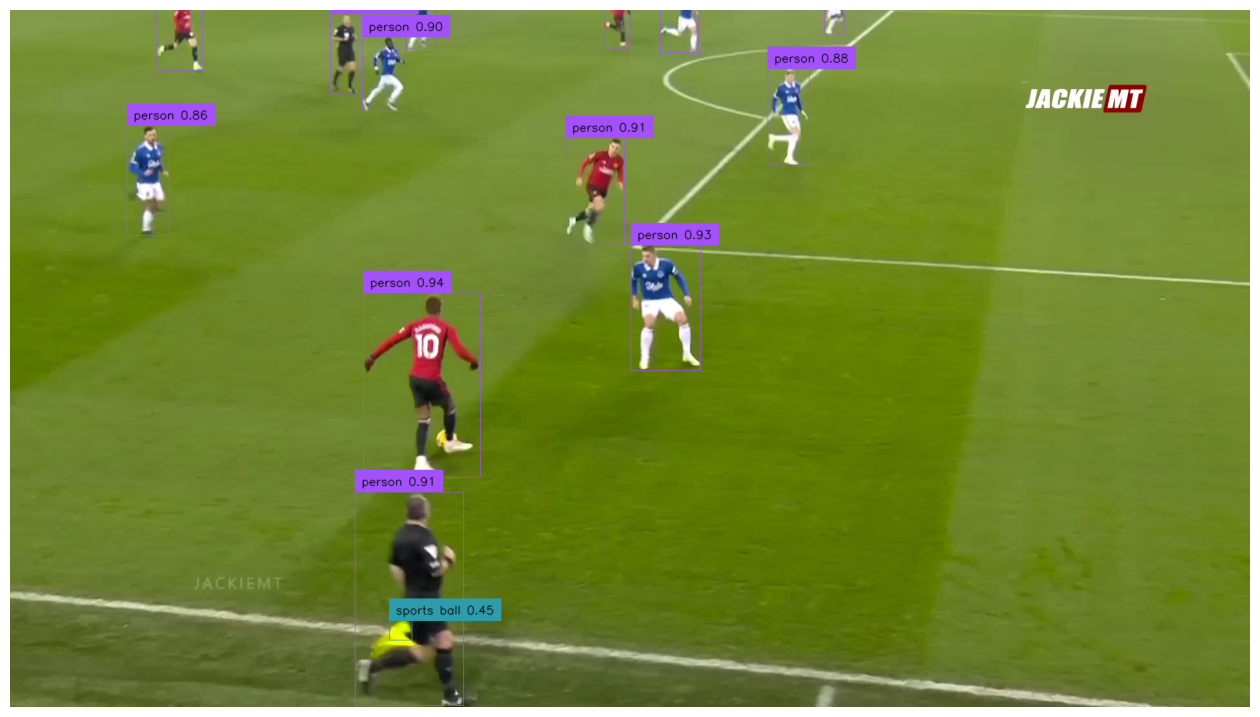

In [16]:
sv.plot_image(annotated_frame, (16, 16))

In [105]:
# now thw whole video operation :

In [20]:
byte_tracker = sv.ByteTrack(
    track_activation_threshold=0.35, # Minimum confidence to start tracking
    lost_track_buffer=30, # If object disappears → keep it alive for 30 frames
    minimum_matching_threshold=0.8, # How strict matching is between frames (IoU-based), 0.8 --> very strict ---> Object must look very similar / overlap strongly to keep same ID
    frame_rate=60,
    minimum_consecutive_frames=3 # Object must appear in at least 3 consecutive frames
)

In [21]:
byte_tracker.reset() # Clears all internal tracking state(existing tracked objects (IDs) + past frame information + matching history) inside the ByteTrack object; needed because ByteTrack remembers previous frames 

In [22]:
LINE_START = sv.Point(0 + 50, 1500)
LINE_END = sv.Point(3840 - 50, 1500)

TARGET_VIDEO_PATH = r"E:\404_Found\Video Segmentation\SuperHuman Moments in FootBall\Object_Detected_Results\results.mp4"

In [23]:
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH) # Reads the video file and creates an object containing its basic properties(like width, height, fps, total frames)
print(video_info)

generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH) # Creates a frame-by-frame iterator over the video, So you can process the video one frame at a time

line_zone = sv.LineZone(start=LINE_START, end=LINE_END)

VideoInfo(width=1920, height=1080, fps=60, total_frames=45914)


In [24]:
box_annotator = sv.BoxAnnotator(thickness=1) # Creates an object that will draw bounding boxes around detections
label_annotator = sv.LabelAnnotator(text_thickness=1, text_scale=0.6, text_color=sv.Color.BLACK) # Creates an object that will draw text labels (like "car 0.91")
trace_annotator = sv.TraceAnnotator(thickness=1, trace_length=50) # Creates an object that will draw motion trails of tracked objects trace_length=50 → keeps last 50 positions (shows movement path)
line_zone_annotator = sv.LineZoneAnnotator(thickness=1, text_thickness=1, text_scale=0.6) # draw the counting line on frame display counts (in/out) near the line

In [25]:
def callback(frame: np.ndarray, index: int) -> np.ndarray:
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[np.isin(detections.class_id, SELECTED_CLASS_IDS)]
    detections = byte_tracker.update_with_detections(detections)
    labels = [
        f"#{tracker_id} {model.model.names[class_id]} {confidence:0.2f}"
        for confidence, class_id, tracker_id
        in zip(detections.confidence, detections.class_id, detections.tracker_id)
    ]
    annotated_frame = frame.copy()
    annotated_frame = trace_annotator.annotate(
        scene=annotated_frame, detections=detections)
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame, detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame, detections=detections, labels=labels)
    line_zone.trigger(detections)
    return line_zone_annotator.annotate(annotated_frame, line_counter=line_zone)

In [26]:
sv.process_video(
    source_path = SOURCE_VIDEO_PATH,
    target_path = TARGET_VIDEO_PATH,
    callback=callback
)